# Setup

In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1550 # [nm]

In [ ]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
chip.turn_off()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('mmi_carac', verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-04-02_065e163/1_topa_scans


In [ ]:
phobos.Config().set('dm.stabilization_time', 0.002, autosave=False)
phobos.Config().set('photonic_chip.stabilization_time', 0.005, autosave=False)

# Check cropping

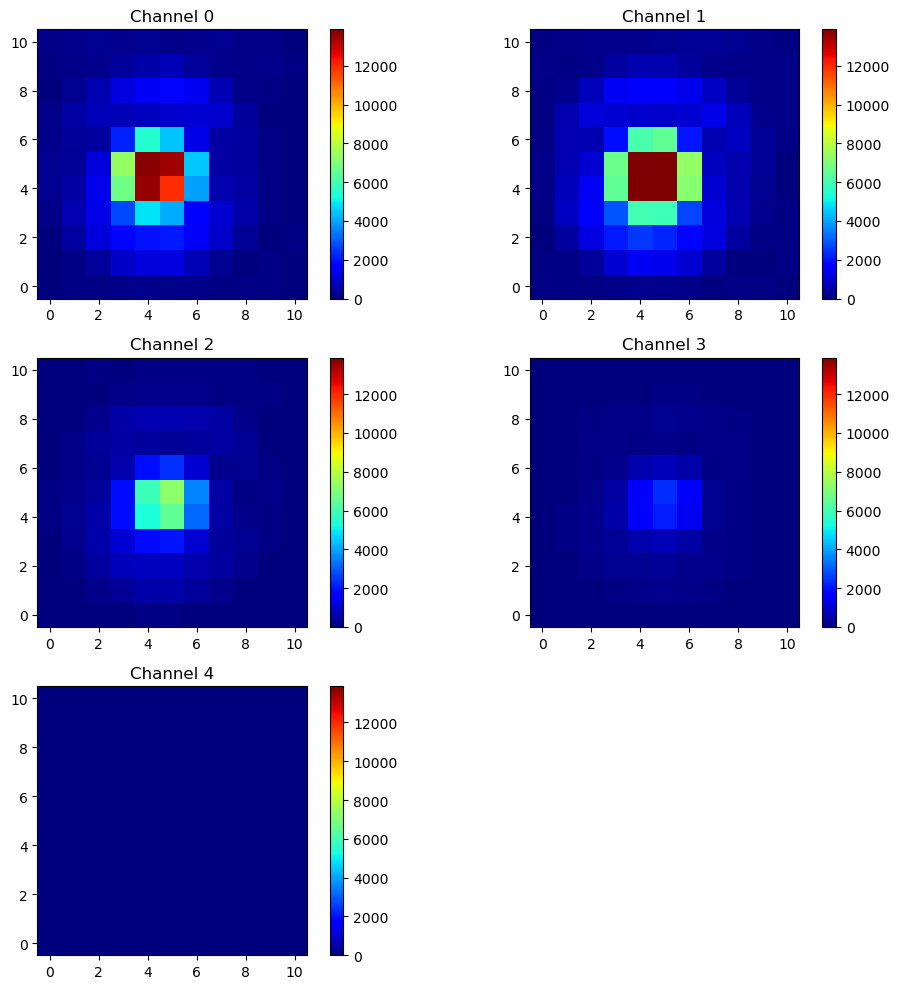

In [5]:
# check cropping
cam.check_cropping()

# Calibrate injection

In [6]:
# Injection calibration
inj = phobos.Injection()


Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:20<01:00, 20.07s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:39<00:38, 19.50s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:53<00:17, 17.12s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:09<00:00, 17.31s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.68353,0.75847) mrad
Injection spread of seg=137: (tip, tilt) = (0.67460,0.77654) mrad
Injection spread of seg=136: (tip, tilt) = (0.69057,0.78133) mrad
Injection spread of seg=135: (tip, tilt) = (0.72105,0.79985) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.42303,0.06907) mrad; flux = 1203
Injection max of seg=137: (tip, tilt) = (-0.11689,-0.08938) mrad; flux = 972.2
Injection max of seg=136: (tip, tilt) = (0.23523,-0.14080) mrad; flux = 1170
Injection max of seg=135: (tip, tilt) = (0.43137,-0.12461) mrad; flux = 1152
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 1 (seg 137), target flux = 1036
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.4913 mrad, flux = 1031 (target 1036), iterations = 13
  Dichotomy on channel 2 (seg 136)…
Injection OFF on channels [0, 1, 3] (segments [138, 137, 135])
    → balanced tilt = 0.2064 mrad, flux = 1028 (target 1036), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.2756 mrad, flux = 1039 (target 1036), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


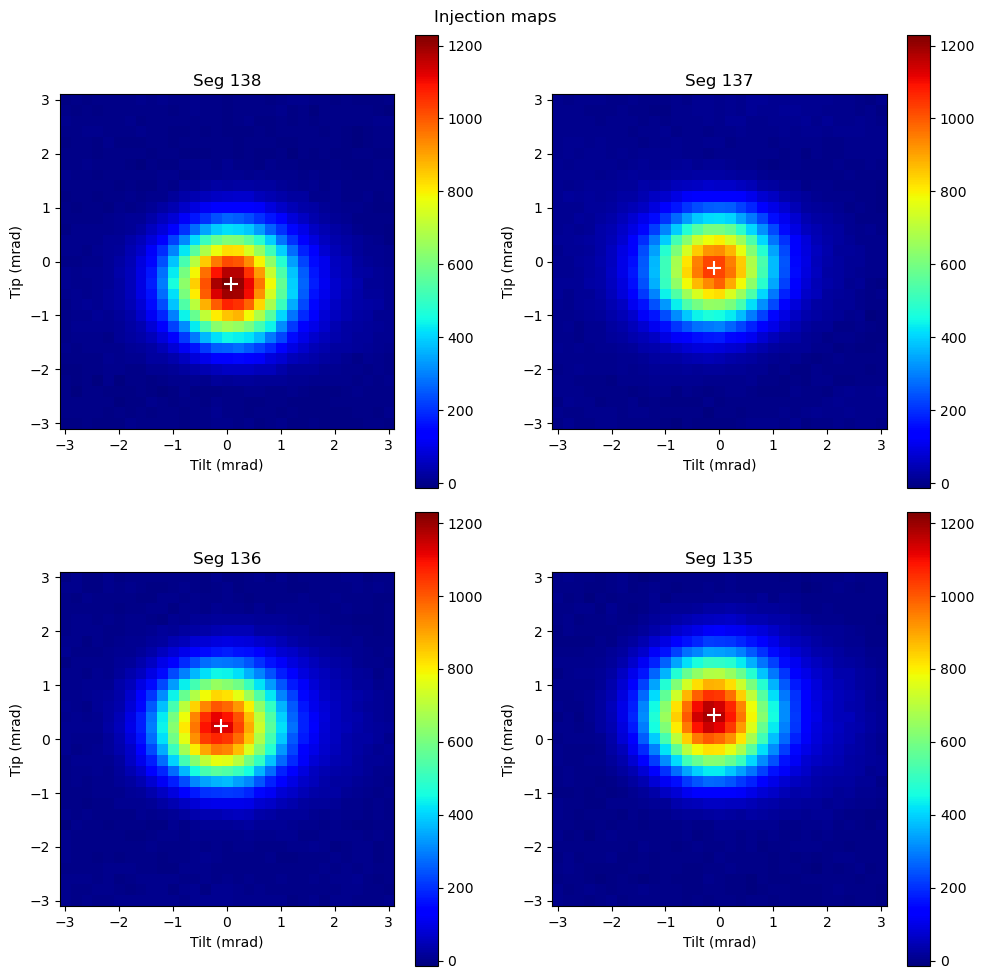

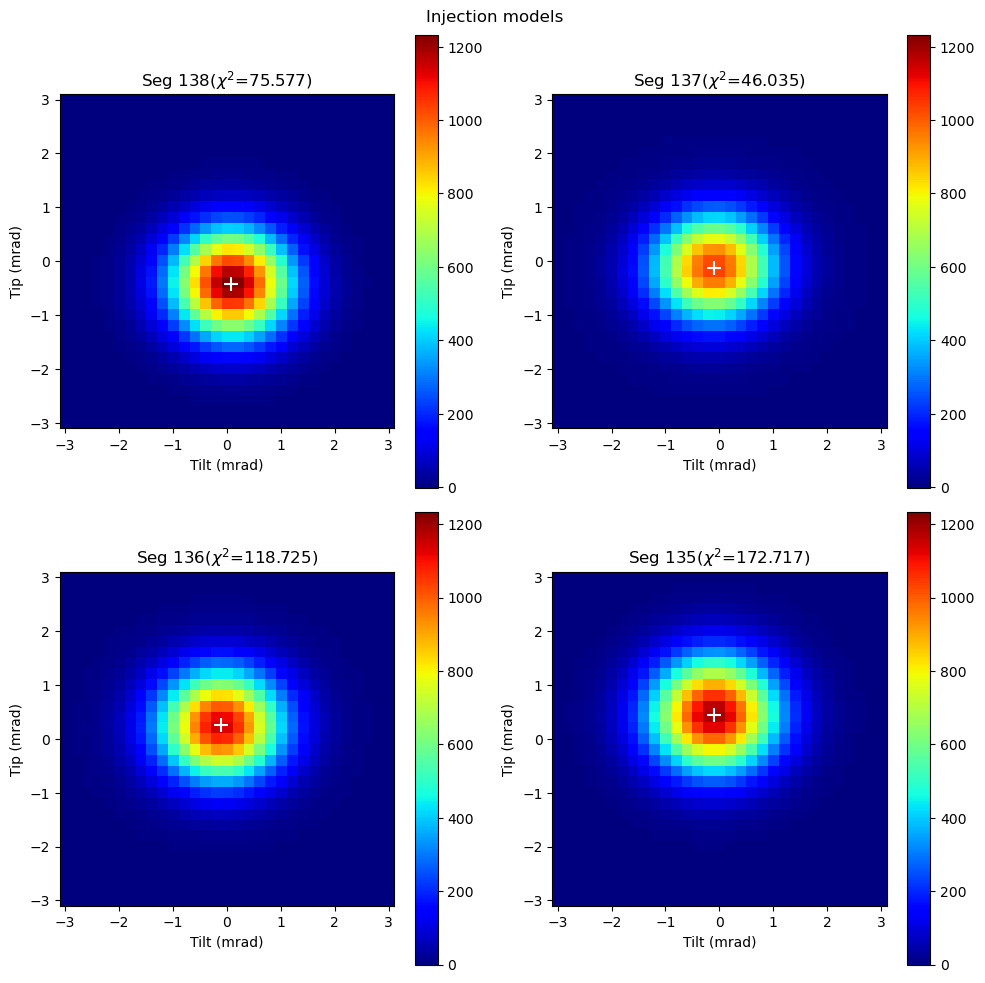

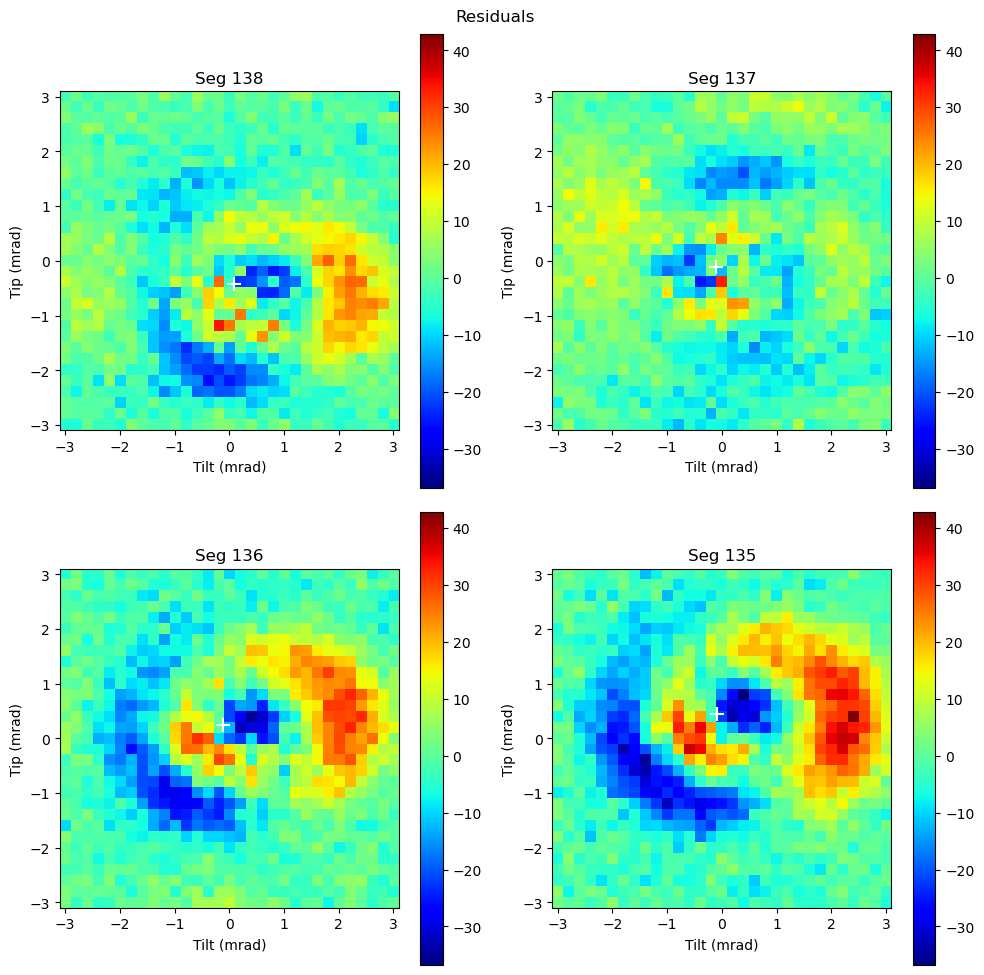

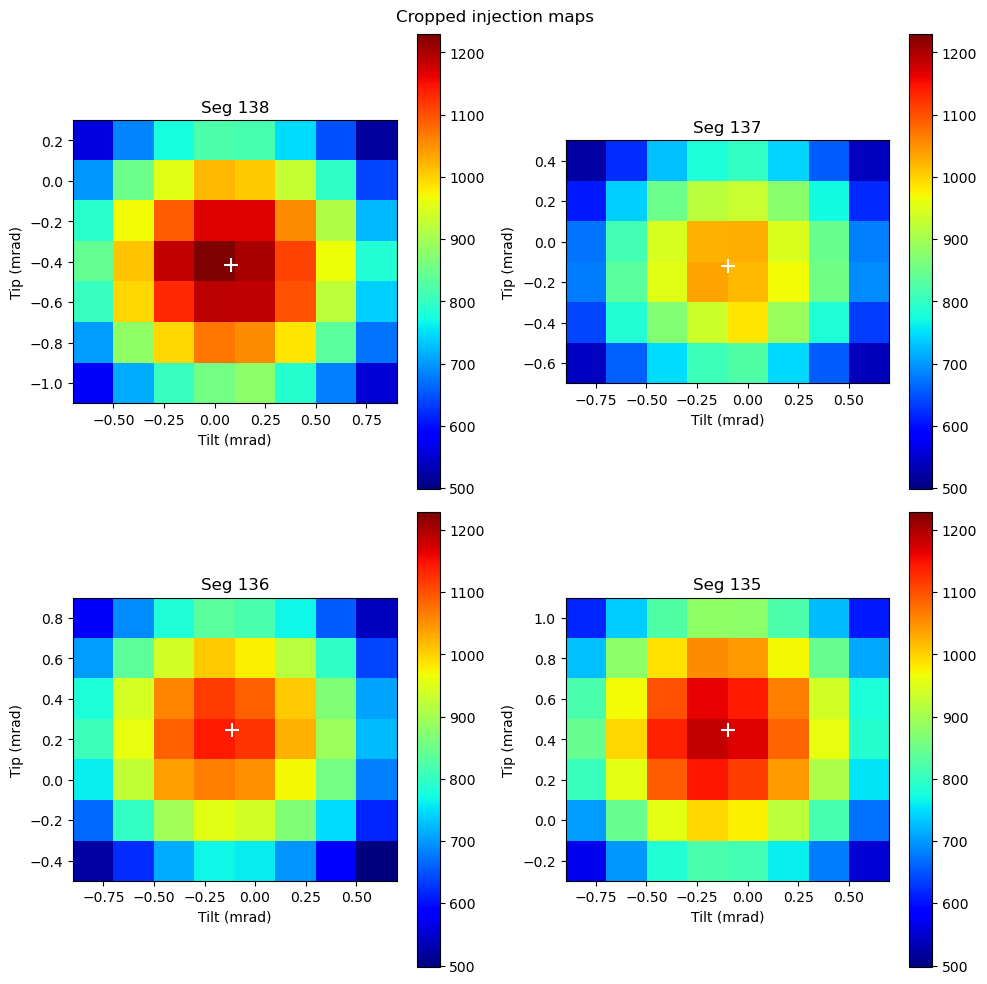

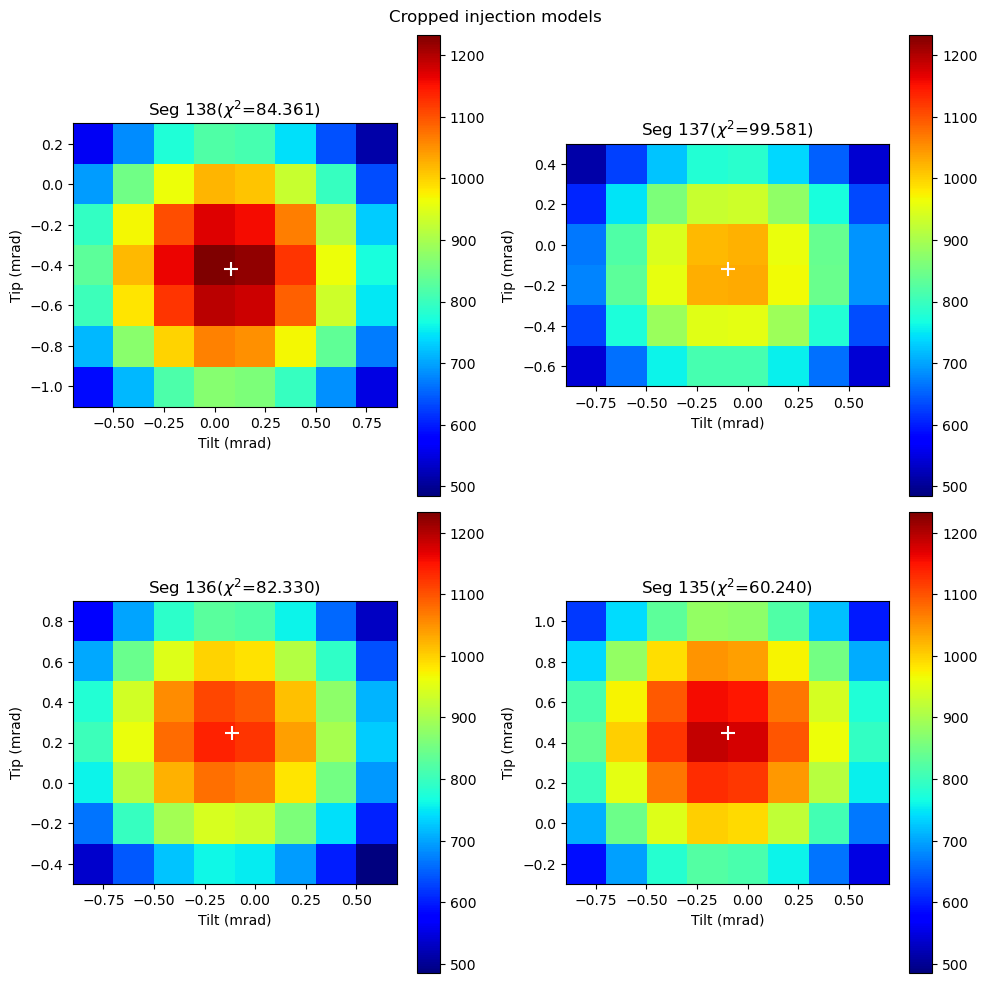

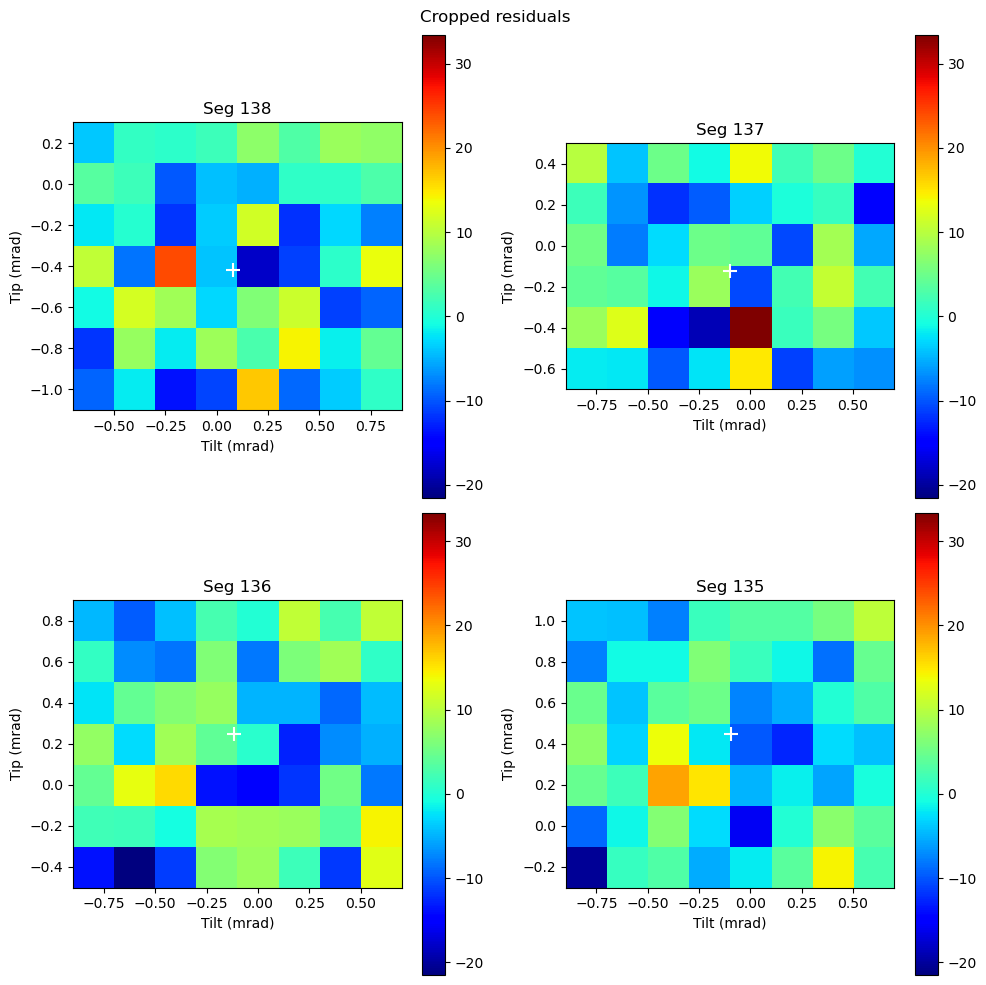

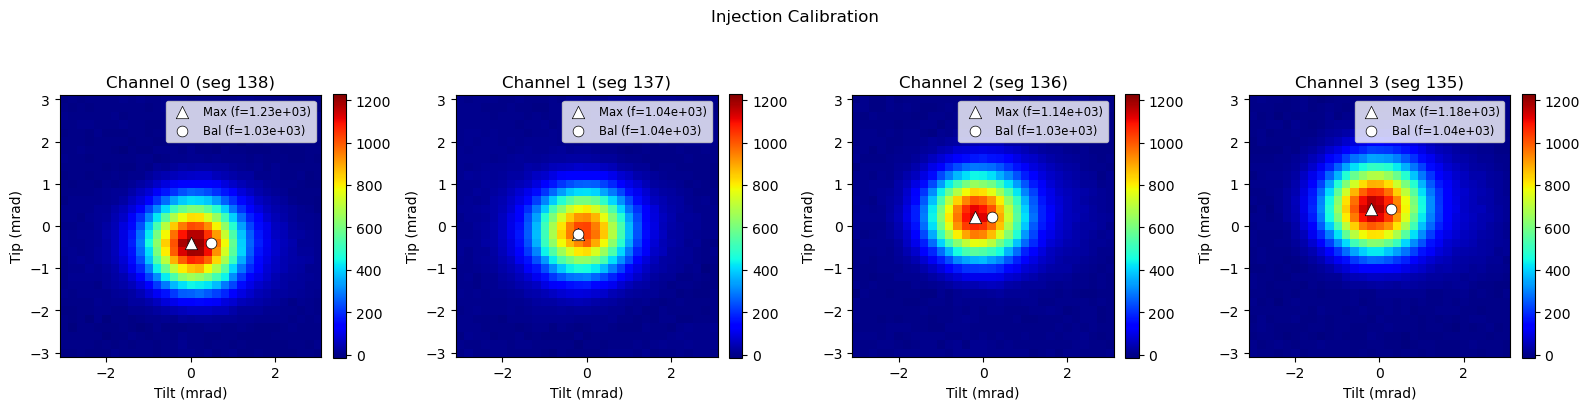

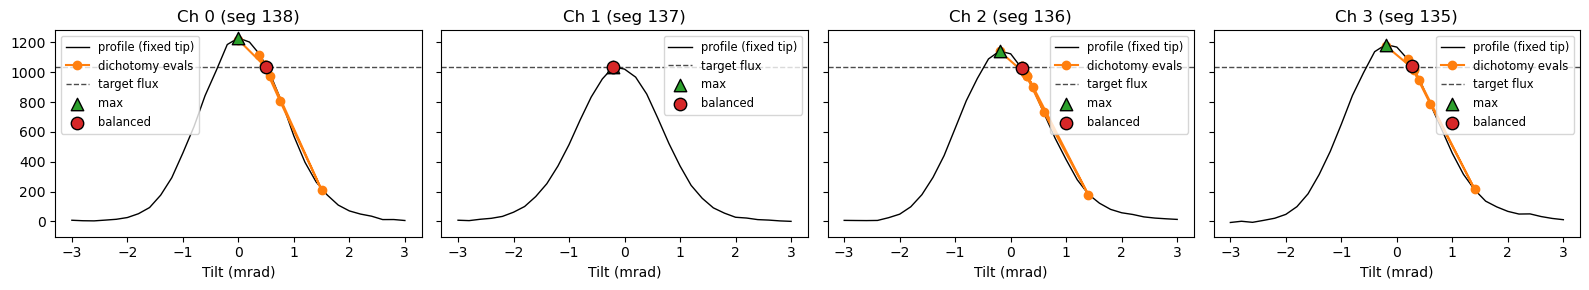

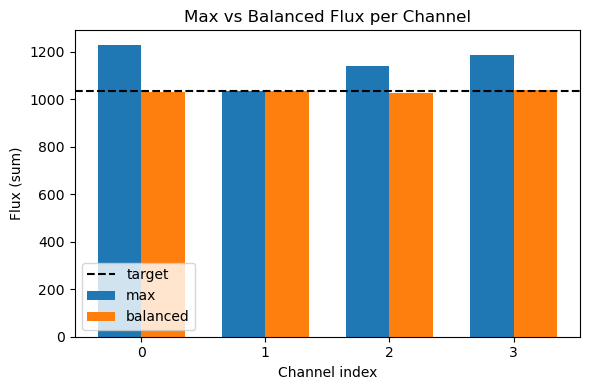

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [7]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol = 0.5e-3)

inj.zero()

# Phase shifter calibration

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
🔧 Calibrating phase for 4 shifters...
  - Scanning shifter 17 1/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 17 2/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 17 3/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 17 4/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 17 5/5
FLUXES (100, 4)
Correcting drift...
Phase-to-power calibration...
  ✅ Shifter 17 calibrated: Period=0.6068 W -> Coeff=0.0966 W/rad
  - Scanning shifter 18 1/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 18 2/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 18 3/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 18 4/5
FLUXES (100, 4)
Correcting drift...
  - Scanning shifter 18 5/5
FLUXES (100, 4)
Correcting drift...
Phase-to-power calibration...
  ✅ Shifter 18 calibrated: Period=0.5962 W -> Coeff=0.0949 W/rad
  - Scanning shifter 19 1/5
FLUXES (100, 4)
Correcting d

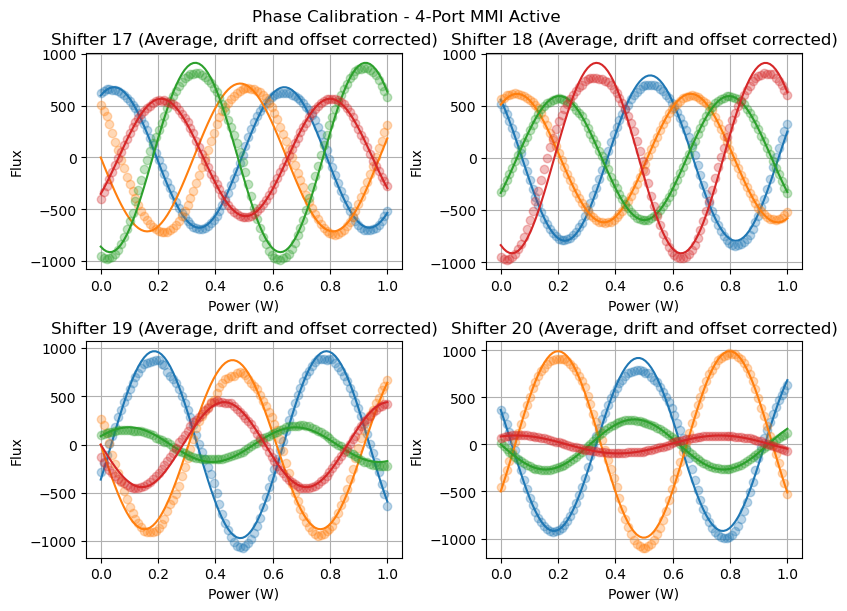

📊 Performing phase scan (0 to 2π) for verification...
  - Scanning phase for shifter 17...
  - Scanning phase for shifter 18...
  - Scanning phase for shifter 19...
  - Scanning phase for shifter 20...


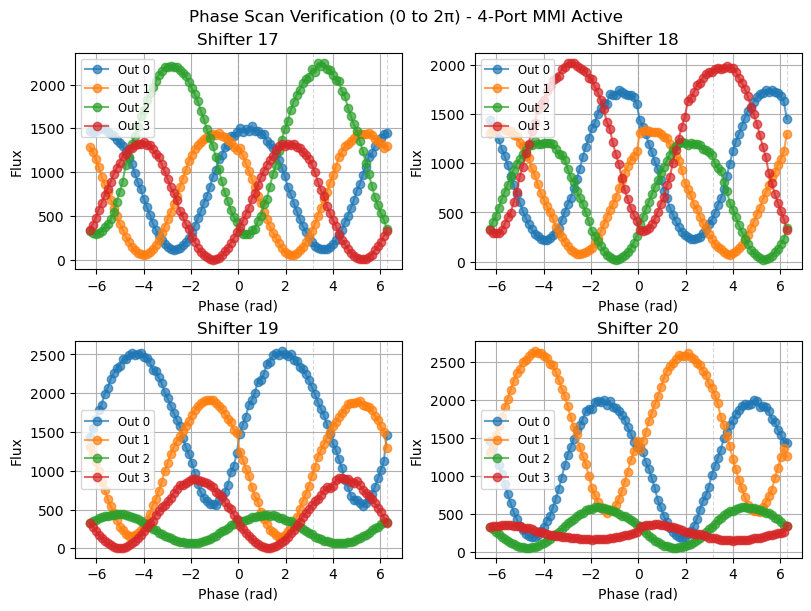

✅ Phase calibration completed.


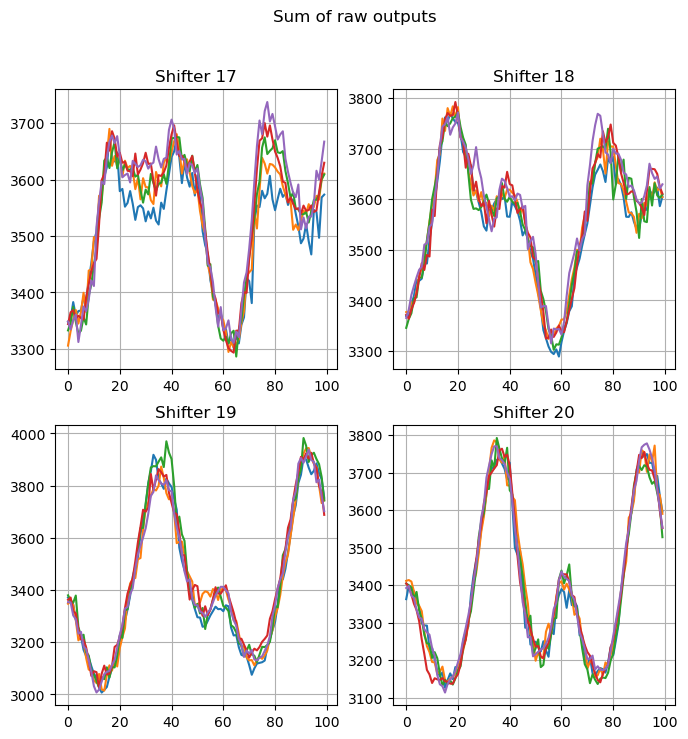

In [8]:
inj.set_balanced()

avg_frames = 5
# TOPAs calibration
chip_coeffs, chip_scans, chip_power_range = chip.phase_calibration2(niter = 5, plot=True, verbose=True, avg_frames=avg_frames)

np.save(path / "chip_coeffs.npy", chip_coeffs)
np.savez(path / "chip_scans.npz", chip_scans=chip_scans, chip_power_range=chip_power_range)

s = chip_scans.sum(3)
plt.figure(figsize=(8,8))
plt.suptitle("Sum of raw outputs")
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(s[i].T)
    plt.grid()
    plt.title(f"Shifter {chip.shifters[i].channel}")

chip.turn_off()
    

# Pair scan with DM

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

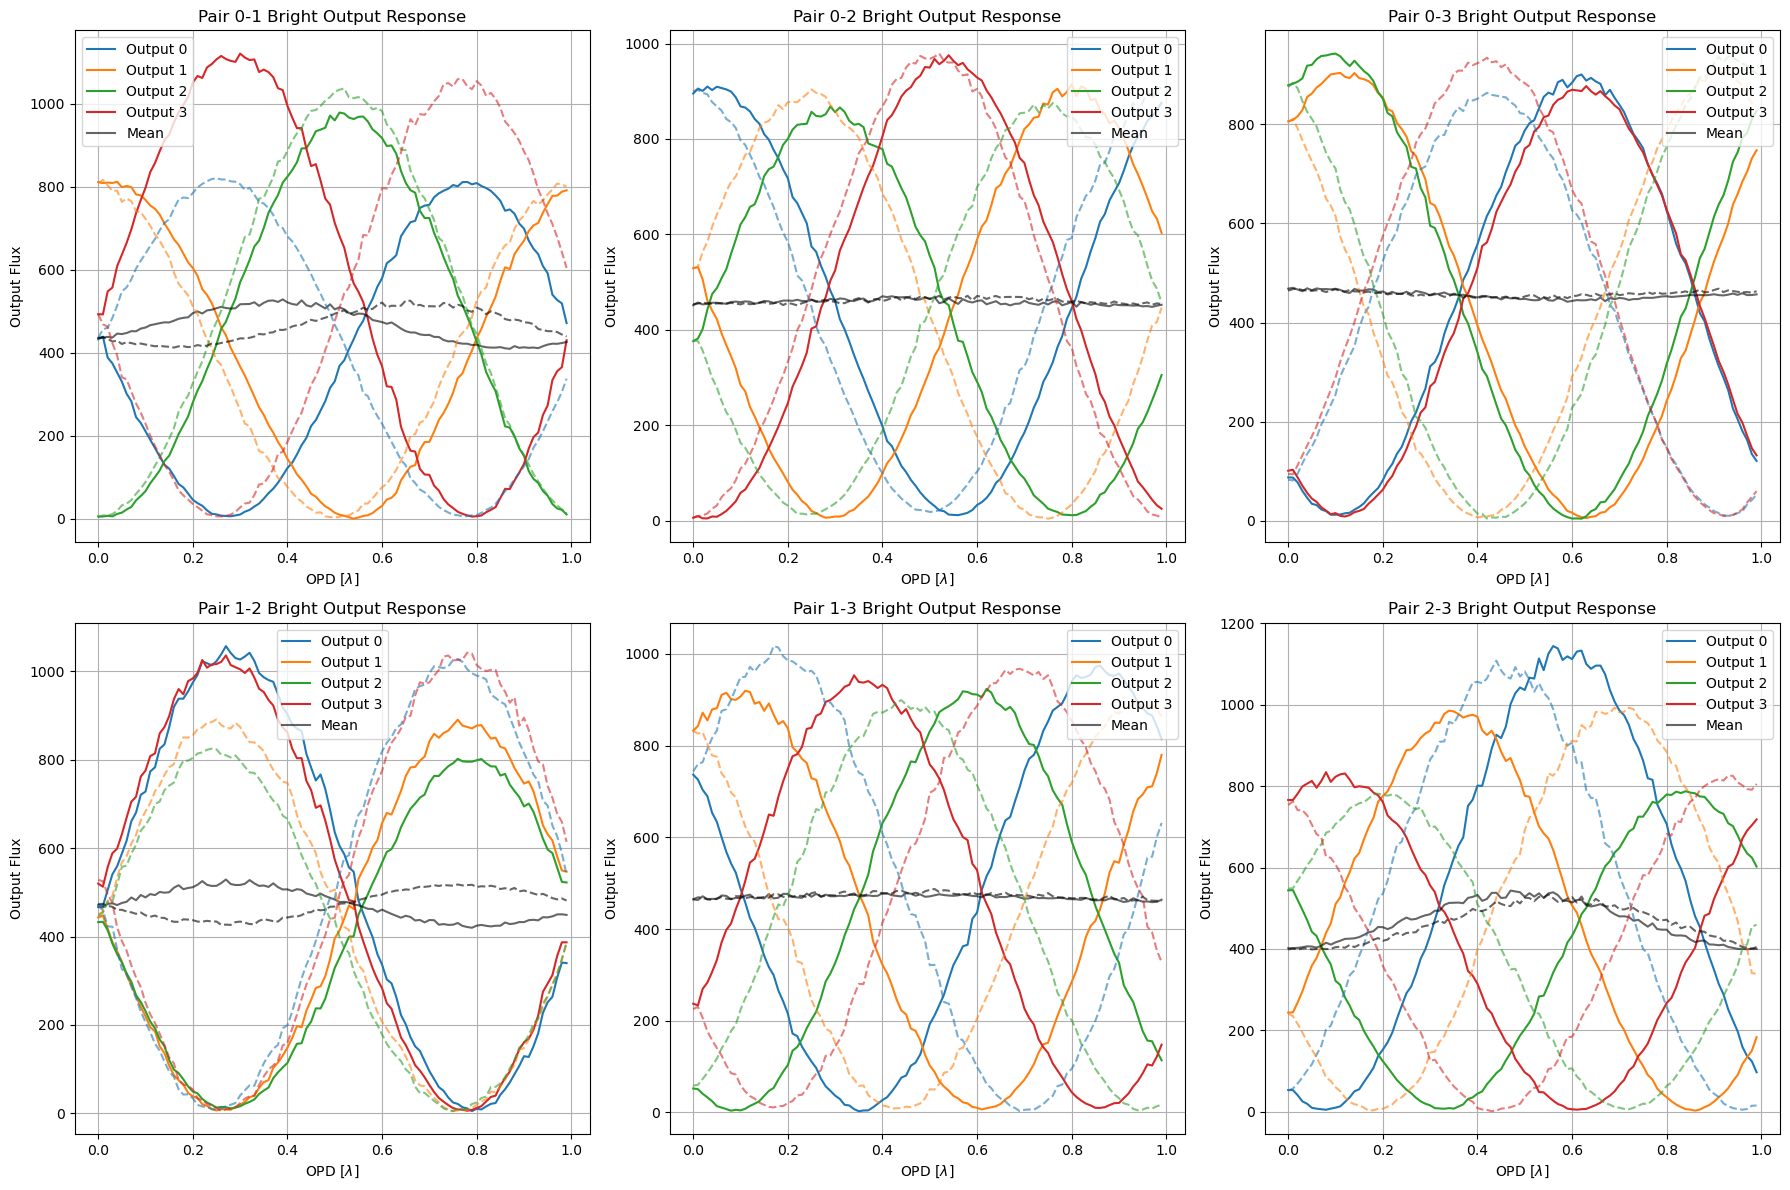

In [ ]:
def scan_dm(piston_range, n_roi, dm, cam, inj_seg, pair, ref_tip, ref_tilt):
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair]].set_ptt(piston, ref_tip, ref_tilt)
        if p == 0:
            time.sleep(0.1)
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    dm[inj_seg[pair]].set_ptt(ref_cart, ref_tip, ref_tilt)
    time.sleep(0.1)

    return outs

pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
nb_lam = 1.
n_roi = cam.get_outputs(flux_mode='mean').size - 1

res_pair_scan = {}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    start = ref_cart - nb_lam * lam/2./2.
    piston_range = np.linspace(start, start + nb_lam * lam/2., 100, endpoint=False)  # [nm]
    opd_range = (piston_range - ref_cart) * 2

    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())

    # Scan on first input
    outs = scan_dm(piston_range, n_roi, dm, cam, inj_seg, pair[0], ref_tip[0], ref_tilt[0])

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[0], pair[1])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='-', alpha=0.6, label='Mean')

    # Scan on second input
    inj.off()
    inj.set_balanced(np.array(pair))

    outs = scan_dm(piston_range, n_roi, dm, cam, inj_seg, pair[1], ref_tip[1], ref_tilt[1])

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='--', alpha=0.6)
    
    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
filename = 'pair_scan_start%.0f_nb_lam%s.png'%(start, nb_lam)
fig.savefig(path + filename)

filename = 'pair_scan_data_start%.0f_nb_lam%s.pkl'%(start, nb_lam)
with open(path + filename, 'wb') as f:
    pickle.dump(res_pair_scan, f)


inj.set_balanced()

# Piston ramp with phase shifter

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

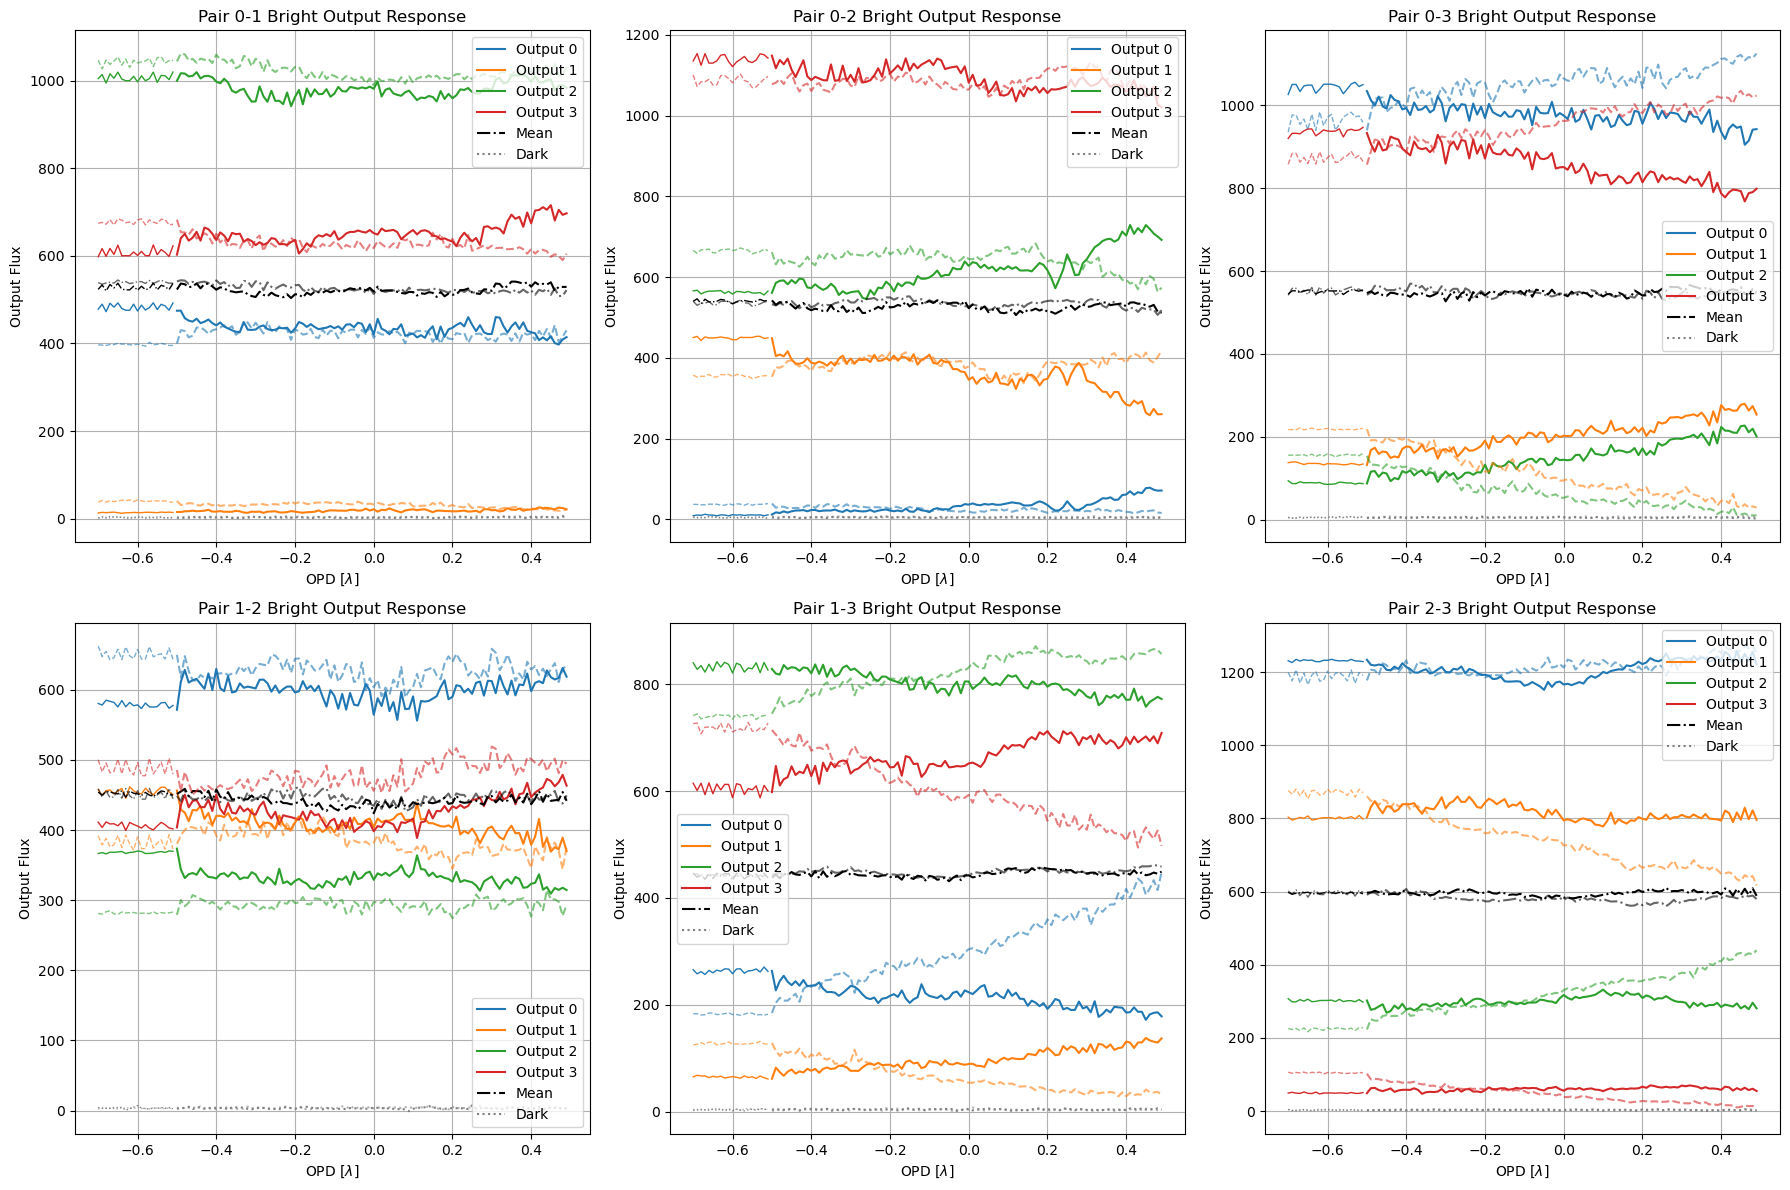

In [ ]:
def scan_ps(opd_range, n_roi, chip, cam, pair, phase_offset):
    pre_outs = np.empty((20, n_roi))
    outs = np.empty((len(opd_range), n_roi))
    for p, piston in enumerate(opd_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phases = np.zeros(4)
        phases[pair] = phase + phase_offset
        chip.set_phases(phases)
        if p == 0:
            time.sleep(0.1)
            for it in range(pre_outs.shape[0]):
                pre_outs[it] = cam.get_outputs(flux_mode='mean')[:n_roi]
        outs[p] = cam.get_outputs(flux_mode='mean')[:n_roi]

    pad_length = len(opd_range) - pre_outs.shape[0]
    pre_outs_padded = np.pad(pre_outs, ((0, pad_length), (0, 0)), mode='constant', constant_values=0)

    return outs, pre_outs_padded, pre_outs

pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
nb_lam = 1.
n_roi = cam.get_outputs(flux_mode='mean').size
phase_offset = np.pi * 1.

# piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_ramp_scan = {}

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'black', 'grey']
for i, pair in enumerate(pairs):
    # Scan on first input
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    start = ref_cart - lam/2./2.
    piston_range = np.linspace(start, start + nb_lam * lam/2., 100, endpoint=False)  # [nm]
    opd_range = (piston_range - ref_cart) * 2

    outs, pre_outs_padded, pre_outs = scan_ps(opd_range, n_roi, chip, cam, pair[0], phase_offset)

    phases = np.zeros(4)
    phases[pair[0]] = 0.
    chip.set_phases(phases)    

    data = np.hstack((opd_range[:,None], outs.copy(), pre_outs_padded))
    res_ramp_scan[(pair[0], pair[1])] = data

    step = np.diff(opd_range)[0]
    pre_out_mock_axis = opd_range[0] + np.arange(-pre_outs.shape[0], 0) * step
 
    for o in range(n_roi-1):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')
        axs[i].plot(pre_out_mock_axis / lam, pre_outs[:, o], color=colors[o], linewidth=1)
    axs[i].plot(opd_range / lam, outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', label='Mean')
    axs[i].plot(opd_range / lam, outs[:,-1], color=colors[-1], linestyle=':', label='Dark')
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', linewidth=1)
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,-1], color=colors[-1], linestyle=':', linewidth=1)

    # Scan on second input
    inj.off()
    chip.set_phases([0,0,0,0])
    inj.set_balanced(np.array(pair))
    time.sleep(0.1)

    ref_cart = dm[inj_seg[pair[0]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    outs, pre_outs_padded, pre_outs = scan_ps(opd_range, n_roi, chip, cam, pair[1], phase_offset)

    phases = np.zeros(4)
    phases[pair[1]] = 0.
    chip.set_phases(phases)

    data = np.hstack((opd_range[:,None], outs.copy(), pre_outs_padded))
    res_ramp_scan[(pair[1], pair[0])] = data

    for o in range(n_roi-1):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
        axs[i].plot(pre_out_mock_axis / lam, pre_outs[:, o], color=colors[o], linestyle='--', linewidth=1, alpha=0.6)
    axs[i].plot(opd_range / lam, outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', alpha=0.6)
    axs[i].plot(opd_range / lam, outs[:,-1], color=colors[-1], linestyle=':', alpha=0.6)
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,:-1].mean(axis=1), color=colors[n_roi-1], linestyle='-.', linewidth=1, alpha=0.6)
    axs[i].plot(pre_out_mock_axis / lam, pre_outs[:,-1], color=colors[-1], linestyle=':', linewidth=1, alpha=0.6)

    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()
    

fig.tight_layout()
filename = 'ramp_nb_start%.1f_lam%.1f_offset_pi.png'%(start, nb_lam)
fig.savefig(path / filename)

filename = 'ramp_data_nb_start%.1f_lam%.1f_offset_pi.pkl'%(start, nb_lam)
with open(path / filename, 'wb') as f:
    pickle.dump(res_ramp_scan, f)

inj.set_balanced()
chip.turn_off()

# The end

In [49]:
print('Path is', path)

inj.zero()

Path is /mnt/disk1/archive/2026-04-01_a43da1f/3_injection_commissioning
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [50]:
phobos.XPOW().turn_off()

# Analysis

In [54]:
def open_pickl(filename):
    with open(filename, 'rb') as f:
        loaded_data = pickle.load(f)
    return loaded_data


Text(0, 0.5, 'Flux (counts)')

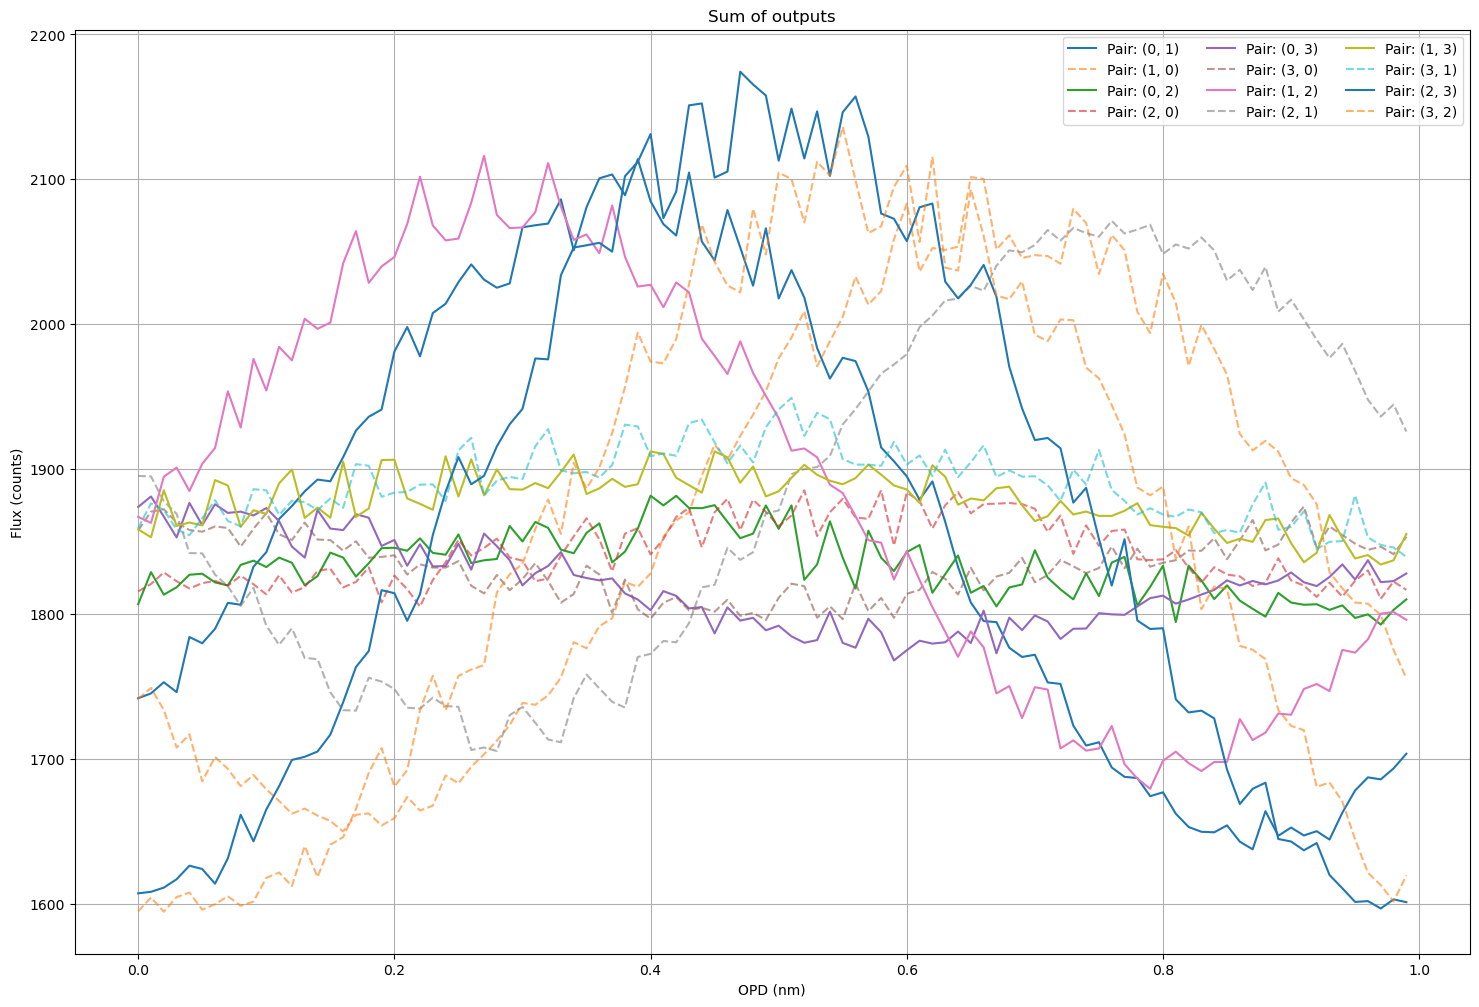

In [85]:
# Pair scan
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
path = '/mnt/disk1/archive/2026-04-02_065e163/1_topa_scans/'
filename = path + 'pair_scan_data_start-1150_nb_lam1.0.pkl'
loaded_data = open_pickl(filename)

plt.figure(figsize=(18,12))
plt.title('Sum of outputs')
for p in pairs:
    value = loaded_data[p]
    plt.plot(value[:,0] / lam, value[:,1:].sum(axis=1), label=f"Pair: {p}")
    p2 = p[::-1]
    value2 = loaded_data[p2]
    plt.plot(value2[:,0] / lam, value2[:,1:].sum(axis=1), '--', alpha=0.6, label=f"Pair: {p2}")
plt.grid()
plt.legend(ncol=3)
plt.xlabel('OPD (nm)')
plt.ylabel('Flux (counts)')

0.3


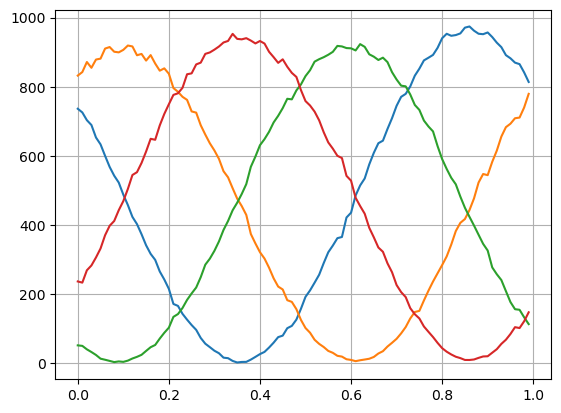

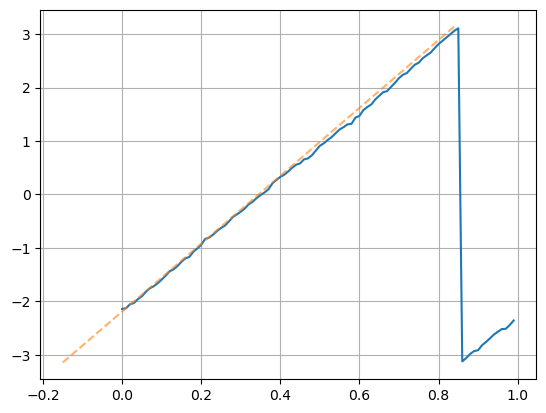

In [95]:
p = (1, 3)
value = loaded_data[p]

plt.figure()
plt.plot(value[:,0] / lam, value[:, 1:])
plt.grid()

fringes = value[:, 1:]
estimator = np.arctan2(-(fringes[:,1] - fringes[:,2]), -(fringes[:,0] - fringes[:,3]))

phase = np.linspace(-np.pi, np.pi, value[:,0].size)

plt.figure()
plt.plot(value[:,0] / lam, estimator)
plt.plot(value[:,0] / lam - 0.15, phase, '--', alpha=0.6)
plt.grid()

print(2*0.15)